# Thresholded Perceptron Implementation
This notebook implements a basic thresholded perceptron. It trains on linearly separable data (AND/OR) and demonstrates failure on non-linearly separable data (XOR).

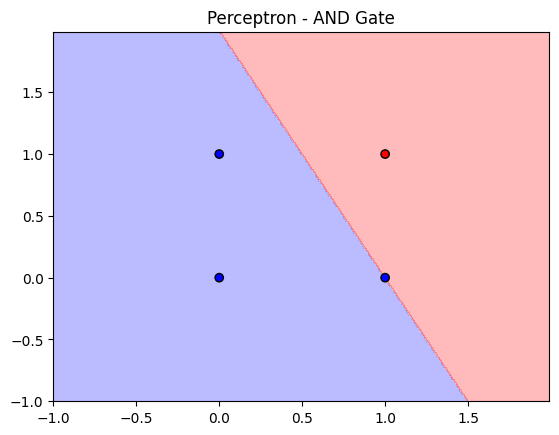

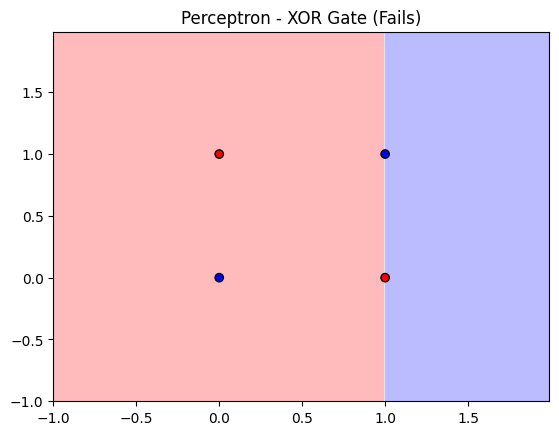

In [1]:
import numpy as np
import matplotlib.pyplot as plt

class ThresholdedPerceptron:
    def __init__(self, learning_rate=0.1, epochs=10):
        self.eta = learning_rate
        self.epochs = epochs
        self.w = None

    def fit(self, X, y):
        # Insert bias term (x0 = 1)
        X_bias = np.c_[np.ones((X.shape[0], 1)), X]
        self.w = np.zeros(X_bias.shape[1])

        for _ in range(self.epochs):
            for xi, target in zip(X_bias, y):
                net = np.dot(xi, self.w)
                output = 1 if net > 0 else -1

                # Perceptron rule: delta_w = eta * (t - o) * x
                delta_w = self.eta * (target - output) * xi
                self.w += delta_w

    def predict(self, X):
        X_bias = np.c_[np.ones((X.shape[0], 1)), X]
        return np.where(np.dot(X_bias, self.w) > 0, 1, -1)

def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k')
    plt.title(title)
    plt.show()

# AND Gate Data (Linearly Separable)
X_and = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_and = np.array([-1, -1, -1, 1])

model_and = ThresholdedPerceptron(learning_rate=0.1, epochs=10)
model_and.fit(X_and, y_and)
plot_decision_boundary(model_and, X_and, y_and, "Perceptron - AND Gate")

# XOR Gate Data (Not Linearly Separable)
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([-1, 1, 1, -1])

model_xor = ThresholdedPerceptron(learning_rate=0.1, epochs=20)
model_xor.fit(X_xor, y_xor)
plot_decision_boundary(model_xor, X_xor, y_xor, "Perceptron - XOR Gate (Fails)")